✅ Archivos cargados
creative_feature_base: (1080, 119)
daily_enriched:        (192315, 67)


,creative_id,campaign_id,advertiser_name,app_name,vertical,format,width,height,language,creative_launch_date,...,fatigue_day,perf_score,overall_ctr,overall_cvr,overall_ipm,overall_roas,ctr_decay_pct,cvr_decay_pct,peak_rolling_ctr_5,has_fatigue
0,500000,20000,PixelForge,PixelForge Legends,gaming,interstitial,360,640,ja,2026-01-19,...,NaN,0.341049,0.003894,0.193880,0.754949,0.673222,-0.785291,-0.089880,0.010206,0
1,500001,20000,PixelForge,PixelForge Legends,gaming,rewarded_video,360,640,en,2026-01-30,...,12.0,0.597840,0.006688,0.222317,1.486797,1.126695,-0.879047,-0.080089,0.015481,1
2,500002,20000,PixelForge,PixelForge Legends,gaming,rewarded_video,360,640,ja,2026-02-03,...,11.0,0.607407,0.007061,0.205595,1.451758,1.108107,-0.883621,0.019260,0.016581,1


,date,campaign_id,creative_id,country,os,days_since_launch,spend_usd,impressions,viewable_impressions,clicks,...,objective,primary_theme,target_age_segment,target_os,start_date,end_date,daily_budget_usd,kpi_goal,campaign_duration_days,hq_region
0,2026-01-19,20000,500000,CA,Android,0,1975.84,317764,271361,4385,...,install,fantasy,45-54,Both,2026-01-19,2026-04-02,5386,CPA,74,LATAM
1,2026-01-19,20000,500000,CA,iOS,0,1547.39,233737,185367,2413,...,install,fantasy,45-54,Both,2026-01-19,2026-04-02,5386,CPA,74,LATAM
2,2026-01-19,20000,500000,ES,Android,0,265.09,62072,48430,578,...,install,fantasy,45-54,Both,2026-01-19,2026-04-02,5386,CPA,74,LATAM



Resumen: creative_feature_base
Filas: 1,080 | Columnas: 119

Tipos de datos:
float64    54
int64      40
str        24
bool        1
Name: count, dtype: int64

Nulos por columna (% top 15):
fatigue_day             81.57
campaign_id              0.00
creative_id              0.00
app_name                 0.00
vertical                 0.00
format                   0.00
advertiser_name          0.00
height                   0.00
language                 0.00
creative_launch_date     0.00
theme                    0.00
hook_type                0.00
cta_text                 0.00
headline                 0.00
subhead                  0.00
dtype: float64

Duplicados (filas completas): 0

Resumen: daily_enriched
Filas: 192,315 | Columnas: 67

Tipos de datos:
str        26
int64      25
float64    15
bool        1
Name: count, dtype: int64

Nulos por columna (% top 15):
cvr                     0.29
campaign_id             0.00
date                    0.00
creative_id             0.00
country   

,creative_id_creative,campaign_id_creative,advertiser_name_creative,app_name_creative,vertical_creative,format_creative,width_creative,height_creative,language_creative,creative_launch_date_creative,...,subhead_chars_daily,objective_daily,primary_theme_daily,target_age_segment_daily,target_os_daily,start_date_daily,end_date_daily,daily_budget_usd_daily,kpi_goal_daily,hq_region_daily
0,500000,20000,PixelForge,PixelForge Legends,gaming,interstitial,360,640,ja,2026-01-19,...,25,install,fantasy,45-54,Both,2026-01-19,2026-04-02,5386,CPA,LATAM
1,500000,20000,PixelForge,PixelForge Legends,gaming,interstitial,360,640,ja,2026-01-19,...,25,install,fantasy,45-54,Both,2026-01-19,2026-04-02,5386,CPA,LATAM
2,500000,20000,PixelForge,PixelForge Legends,gaming,interstitial,360,640,ja,2026-01-19,...,25,install,fantasy,45-54,Both,2026-01-19,2026-04-02,5386,CPA,LATAM
3,500000,20000,PixelForge,PixelForge Legends,gaming,interstitial,360,640,ja,2026-01-19,...,25,install,fantasy,45-54,Both,2026-01-19,2026-04-02,5386,CPA,LATAM
4,500000,20000,PixelForge,PixelForge Legends,gaming,interstitial,360,640,ja,2026-01-19,...,25,install,fantasy,45-54,Both,2026-01-19,2026-04-02,5386,CPA,LATAM


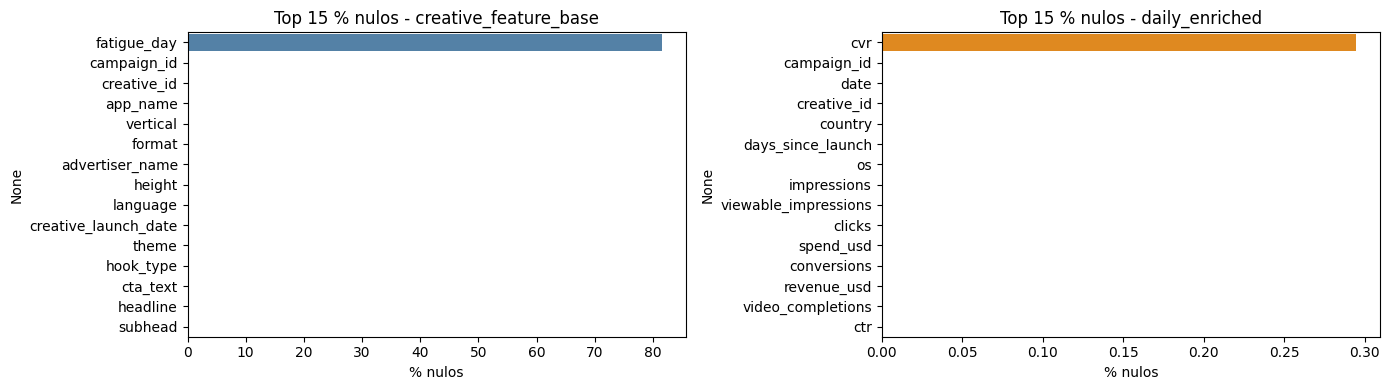

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

# --- Config ---
creative_path = "processed/creative_feature_base.csv"
daily_path = "processed/daily_enriched.csv"

def leer_csv_robusto(path):
	"""Intenta leer CSV con separador/encoding flexibles."""
	for enc in ["utf-8", "latin1"]:
		try:
			return pd.read_csv(path, sep=None, engine="python", encoding=enc)
		except Exception:
			pass
	# último intento estándar
	return pd.read_csv(path)

# --- Lectura ---
creative_df = leer_csv_robusto(creative_path)
daily_df = leer_csv_robusto(daily_path)

print("✅ Archivos cargados")
print(f"creative_feature_base: {creative_df.shape}")
print(f"daily_enriched:        {daily_df.shape}")

display(creative_df.head(3))
display(daily_df.head(3))

# --- Resumen rápido ---
def resumen_df(df, nombre):
	print(f"\n{'='*70}\nResumen: {nombre}")
	print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
	print("\nTipos de datos:")
	print(df.dtypes.value_counts())
	print("\nNulos por columna (% top 15):")
	nulos_pct = (df.isna().mean() * 100).sort_values(ascending=False).head(15)
	print(nulos_pct.round(2))
	print("\nDuplicados (filas completas):", df.duplicated().sum())

resumen_df(creative_df, "creative_feature_base")
resumen_df(daily_df, "daily_enriched")

# --- Comparación de estructura ---
cols_creative = set(creative_df.columns)
cols_daily = set(daily_df.columns)

comunes = sorted(cols_creative & cols_daily)
solo_creative = sorted(cols_creative - cols_daily)
solo_daily = sorted(cols_daily - cols_creative)

print(f"\nColumnas en común ({len(comunes)}):")
print(comunes[:30], "..." if len(comunes) > 30 else "")

print(f"\nSolo en creative_feature_base ({len(solo_creative)}):")
print(solo_creative[:30], "..." if len(solo_creative) > 30 else "")

print(f"\nSolo en daily_enriched ({len(solo_daily)}):")
print(solo_daily[:30], "..." if len(solo_daily) > 30 else "")

# --- Análisis numérico básico ---
num_creative = creative_df.select_dtypes(include=np.number)
num_daily = daily_df.select_dtypes(include=np.number)

if not num_creative.empty:
	print("\nTop varianza (creative_feature_base):")
	print(num_creative.var(numeric_only=True).sort_values(ascending=False).head(10))

if not num_daily.empty:
	print("\nTop varianza (daily_enriched):")
	print(num_daily.var(numeric_only=True).sort_values(ascending=False).head(10))

# --- Intento de cruce entre ambos datasets ---
# Busca posibles claves comunes por nombre
keys_sugeridas = [c for c in comunes if any(k in c.lower() for k in ["id", "date", "fecha", "day"])]
print("\nPosibles claves de cruce:", keys_sugeridas)

if keys_sugeridas:
	# Usa hasta 2 claves para evitar joins excesivos por accidente
	merge_keys = keys_sugeridas[:2]
	merged = creative_df.merge(daily_df, on=merge_keys, how="inner", suffixes=("_creative", "_daily"))
	print(f"\nMerge INNER usando {merge_keys}: {merged.shape}")
	if merged.shape[0] > 0:
		print("Muestra de filas combinadas:")
		display(merged.head(5))
else:
	print("\nNo se detectaron claves obvias para hacer merge automáticamente.")

# --- Visual rápido de nulos por dataset ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

creative_nulls = creative_df.isna().mean().sort_values(ascending=False).head(15)
daily_nulls = daily_df.isna().mean().sort_values(ascending=False).head(15)

sns.barplot(x=creative_nulls.values * 100, y=creative_nulls.index, ax=axes[0], color="steelblue")
axes[0].set_title("Top 15 % nulos - creative_feature_base")
axes[0].set_xlabel("% nulos")

sns.barplot(x=daily_nulls.values * 100, y=daily_nulls.index, ax=axes[1], color="darkorange")
axes[1].set_title("Top 15 % nulos - daily_enriched")
axes[1].set_xlabel("% nulos")

plt.tight_layout()
plt.show()